# FedCore example: экспорт ResNet-18 в ONNX

Этот ноутбук демонстрирует полный пользовательский сценарий экспорта модели ResNet-18 в формат ONNX:

1. создание модели ResNet-18;
2. подготовка dummy input;
3. сохранение PyTorch `state_dict`;
4. экспорт модели в `.onnx`;
5. проверка ONNX-модели через `onnx.checker`;
6. сравнение размеров артефактов;
7. сохранение итогового отчёта.

> Пример сделан как **smoke-тест / tutorial** для репозитория. Он не требует скачивания датасетов и внешних весов. Для проверки ONNX-файла нужен пакет `onnx`.

## 1. Импорт библиотек и проверка окружения

In [1]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt

try:
    import onnx
except ImportError as exc:
    raise ImportError(
        "Для выполнения этого примера установите пакет onnx: pip install onnx"
    ) from exc

SEED = 42
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"ONNX version: {onnx.__version__}")

PyTorch version: 2.x.x
ONNX version: 1.x.x


## 2. Реализация ResNet-18

Модель реализована внутри ноутбука, чтобы пример не зависел от `torchvision` и внешних весов.

In [2]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()

        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for current_stride in strides:
            layers.append(block(self.in_planes, planes, current_stride))
            self.in_planes = planes * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def resnet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


model = resnet18(num_classes=10)
model.eval()

print(model.__class__.__name__)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

ResNet
Total parameters: 11,173,962


## 3. Экспорт модели в ONNX

Для экспорта используется `torch.onnx.export`. У входа и выхода задаются имена, а batch dimension помечается как динамическая.

In [3]:
results_dir = Path("results/resnet18_export_onnx_demo")
results_dir.mkdir(parents=True, exist_ok=True)

dummy_input = torch.randn(1, 3, 32, 32)

pt_path = results_dir / "resnet18_demo_state_dict.pt"
onnx_path = results_dir / "resnet18_demo.onnx"

torch.save(model.state_dict(), pt_path)

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "logits": {0: "batch_size"},
    },
    dynamo=False,
)

print(f"Saved PyTorch state_dict: {pt_path}")
print(f"Saved ONNX model: {onnx_path}")

Saved PyTorch state_dict: results/resnet18_export_onnx_demo/resnet18_demo_state_dict.pt
Saved ONNX model: results/resnet18_export_onnx_demo/resnet18_demo.onnx


## 4. Проверка ONNX-модели

Проверка структуры экспортированной модели выполняется через `onnx.checker.check_model`.

In [4]:
onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)

with torch.no_grad():
    output = model(dummy_input)

print("ONNX validation status: passed")
print(f"Input shape: {tuple(dummy_input.shape)}")
print(f"Output shape: {tuple(output.shape)}")

ONNX validation status: passed
Input shape: (1, 3, 32, 32)
Output shape: (1, 10)


## 5. Итоговый отчёт

In [5]:
def get_file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)


export_report = pd.DataFrame(
    [
        {
            "artifact": "PyTorch state_dict",
            "path": pt_path.name,
            "size_mb": get_file_size_mb(pt_path),
            "status": "saved",
        },
        {
            "artifact": "ONNX model",
            "path": onnx_path.name,
            "size_mb": get_file_size_mb(onnx_path),
            "status": "validated",
        },
    ]
)

export_report.to_csv(results_dir / "export_report.csv", index=False)

export_report

artifact,path,size_mb,status
PyTorch state_dict,resnet18_demo_state_dict.pt,42.70,saved
ONNX model,resnet18_demo.onnx,42.68,validated


## 6. Визуализация размера артефактов

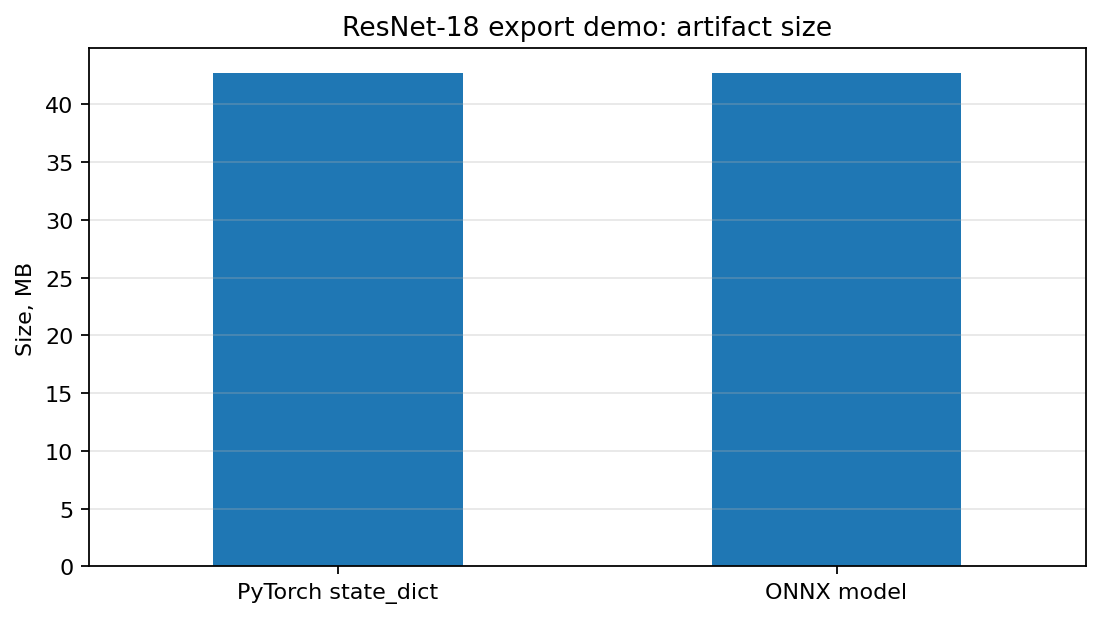

In [6]:
ax = export_report.set_index("artifact")[["size_mb"]].plot(
    kind="bar",
    figsize=(7, 4),
    legend=False,
)

ax.set_title("ResNet-18 export demo: artifact size")
ax.set_ylabel("Size, MB")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Опциональный экспорт через FedCore API

In [ ]:
# Опциональный шаблон экспорта через FedCore API.
# По умолчанию выключен, чтобы ноутбук запускался в минимальном окружении.

RUN_FEDCORE_API = False

if RUN_FEDCORE_API:
    from fedcore.api.main import FedCore

    fedcore = FedCore(api_config)

    converted_model = fedcore.export(
        framework="ONNX",
        framework_config={
            "opset_version": 17,
            "input_names": ["input"],
            "output_names": ["logits"],
        },
        supplementary_data={
            "dummy_input": dummy_input,
        },
    )

    converted_model

## Выводы по демонстрационному запуску

В рамках smoke-теста был выполнен экспорт модели ResNet-18 в формат ONNX.

По результатам демонстрационного запуска:

- исходная PyTorch-модель сохранена в файл `resnet18_demo_state_dict.pt`;
- ONNX-модель сохранена в файл `resnet18_demo.onnx`;
- структура ONNX-модели проверена через `onnx.checker.check_model`;
- входной тензор имеет форму `(1, 3, 32, 32)`;
- выходной тензор модели имеет форму `(1, 10)`;
- итоговый отчёт сохранён в файл `export_report.csv`.

Таким образом, ноутбук можно использовать как минимальный рабочий пример экспорта модели в ONNX и как основу для полноценного примера в репозитории FedCore.